# STEP 1 — Import Libraries

In [1]:
import os
import warnings
import tempfile

warnings.filterwarnings("ignore")

# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
# 1. Create a directory on D: for all temporary "heavy lifting"
d_drive_temp = "D:\\Thesis_Temp_Storage"
if not os.path.exists(d_drive_temp):
    os.makedirs(d_drive_temp)

# 2. Redirect the Environment Variables
# This tells Joblib (used by RandomizedSearchCV) to use D: instead of C:
os.environ['JOBLIB_TEMP_FOLDER'] = d_drive_temp

# 3. Redirect the general Python temp directory
tempfile.tempdir = d_drive_temp

print(f"Success! Temporary storage redirected to: {d_drive_temp}")

Success! Temporary storage redirected to: D:\Thesis_Temp_Storage


# STEP 2 — Clean Data

In [3]:
df = pd.read_csv("Training-data.csv")
print("Shape:", df.shape)

Shape: (440833, 12)


In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [5]:
# Check shape
print("Shape:", df.shape)


Shape: (440833, 12)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [7]:
df.isnull().sum()
df.dropna(inplace=True)

In [8]:
df.dropna(inplace=True)

In [9]:
df['Churn'].value_counts(normalize=True)

Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64

<Axes: xlabel='Churn'>

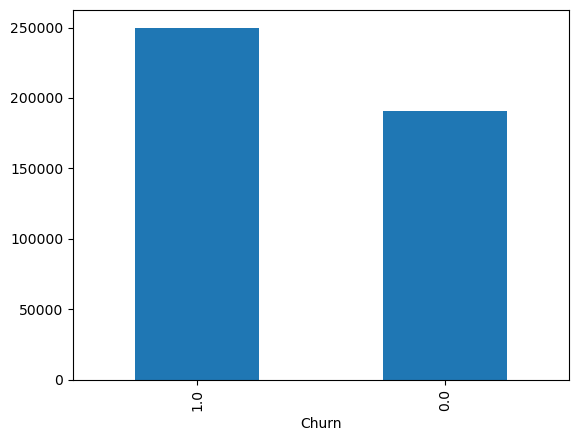

In [10]:
df['Churn'].value_counts().plot(kind='bar')

In [11]:
df["Avg_Spend_Per_Tenure"] = df["Total Spend"] / (df["Tenure"] + 1)

In [12]:
df["Usage_Per_Tenure"] = df["Usage Frequency"] / (df["Tenure"] + 1)

In [13]:
df["Support_Call_Rate"] = df["Support Calls"] / (df["Tenure"] + 1)

In [14]:
df["Payment_Delay_Rate"] = df["Payment Delay"] / (df["Tenure"] + 1)

In [15]:
df["Recency_Score"] = 1 / (df["Last Interaction"] + 1)

In [16]:
df["Engagement_Score"] = (
    df["Usage_Per_Tenure"] 
    - df["Support_Call_Rate"] 
    - df["Payment_Delay_Rate"]
)

In [17]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18,25,35,45,55,65,100],
    labels=["18-25","26-35","36-45","46-55","56-65","65+"]
)

In [18]:
df["High_Risk"] = np.where(
    (df["Support Calls"] > df["Support Calls"].median()) &
    (df["Payment Delay"] > df["Payment Delay"].median()),
    1, 0
)

In [19]:
print(df.shape)

(440832, 20)


In [20]:
cat_cols = ["Gender", "Subscription Type", "Contract Length", "Age_Group"]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [21]:
print(df.shape)

(440832, 26)


In [22]:
## Outlier detection 
num_cols = df.select_dtypes(include=['int64','float64']).columns

num_data = df[num_cols]

In [23]:
num_data.describe(percentiles=[.25, .5, .75, .90, .95, .99])

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Avg_Spend_Per_Tenure,Usage_Per_Tenure,Support_Call_Rate,Payment_Delay_Rate,Recency_Score,Engagement_Score,High_Risk
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,4.408320e+05,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107,36.802808,0.925798,0.217487,0.771985,0.108782,-6.367364e-02,0.232955
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477,53.698272,1.461380,0.427803,1.331052,0.105522,1.258816e+00,0.422714
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000,1.639344,0.016393,0.000000,0.000000,0.032258,-1.900000e+01,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000,12.770748,0.256410,0.033333,0.185185,0.043478,-3.157895e-01,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000,19.439757,0.500000,0.094340,0.388889,0.066667,-2.775558e-17,0.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000,35.985595,0.935484,0.217391,0.758621,0.125000,2.857143e-01,0.000000
90%,403863.900000,57.000000,55.000000,28.000000,9.000000,25.000000,932.000000,27.000000,1.000000,79.493873,2.000000,0.500000,1.666667,0.250000,6.875000e-01,1.000000
95%,425905.450000,61.000000,58.000000,29.000000,10.000000,28.000000,965.894500,29.000000,1.000000,128.064589,3.285714,0.833333,2.800000,0.333333,1.200000e+00,1.000000
99%,443538.690000,65.000000,60.000000,30.000000,10.000000,30.000000,993.020000,30.000000,1.000000,303.681267,8.000000,2.250000,7.250000,0.500000,3.500000e+00,1.000000


In [24]:
## Lets transform some variables where there is skewness
## Large jump after 95th percentile.

df["Avg_Spend_Per_Tenure"] = np.log1p(df["Avg_Spend_Per_Tenure"])
df["Usage_Per_Tenure"] = np.log1p(df["Usage_Per_Tenure"])
df["Payment_Delay_Rate"] = np.log1p(df["Payment_Delay_Rate"])

In [25]:
df["Payment_Delay_Rate"] = np.log1p(df["Payment_Delay_Rate"])

In [26]:
## Some more Cleaning
df = df.drop("CustomerID", axis=1)
cols_to_drop = [
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]
df = df.drop(cols_to_drop, axis=1)
df = df.drop("Age", axis=1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"Final shape for modeling: {df.shape}")

Final shape for modeling: (440832, 18)


In [27]:
import numpy as np
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Final shape for modeling: {df.shape}")

Final shape for modeling: (440832, 18)


In [28]:
# Importing matplotlib and seaborn
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

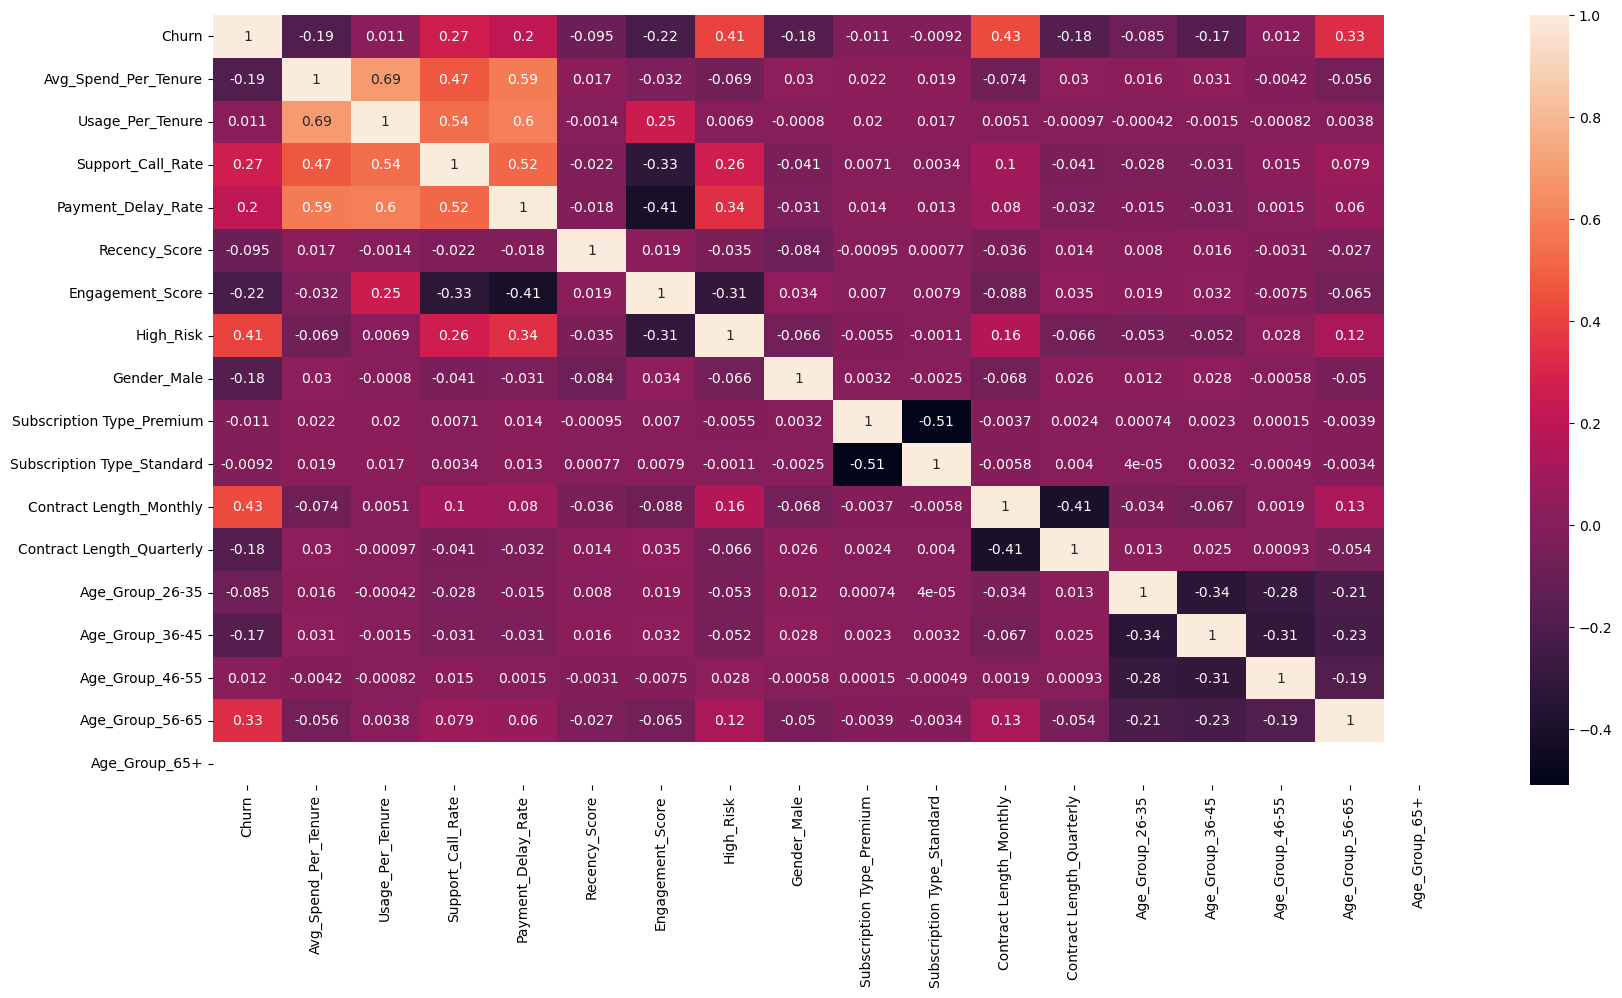

In [29]:
# Let's see the correlation matrix
plt.figure(figsize=(20,10))  # Size of the figure
sns.heatmap(df.corr(), annot=True)
# Save the heatmap
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

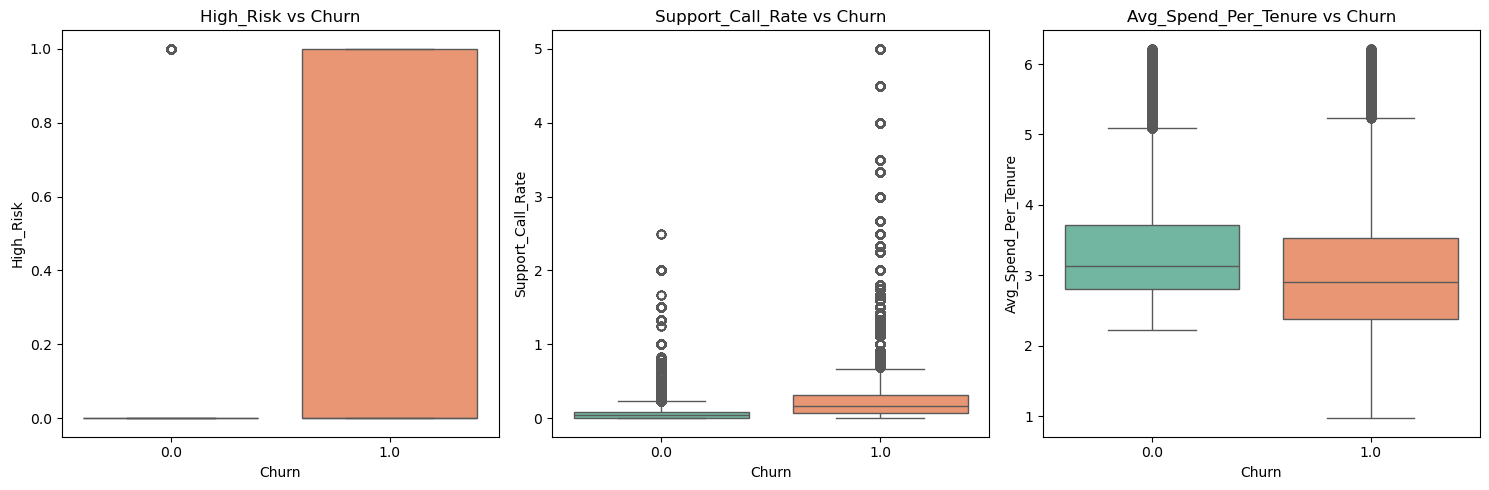

In [30]:
# We will plot the 3 features that showed the highest heatmap correlation
features_to_plot = ['High_Risk', 'Support_Call_Rate', 'Avg_Spend_Per_Tenure']

plt.figure(figsize=(15, 5))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Churn', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

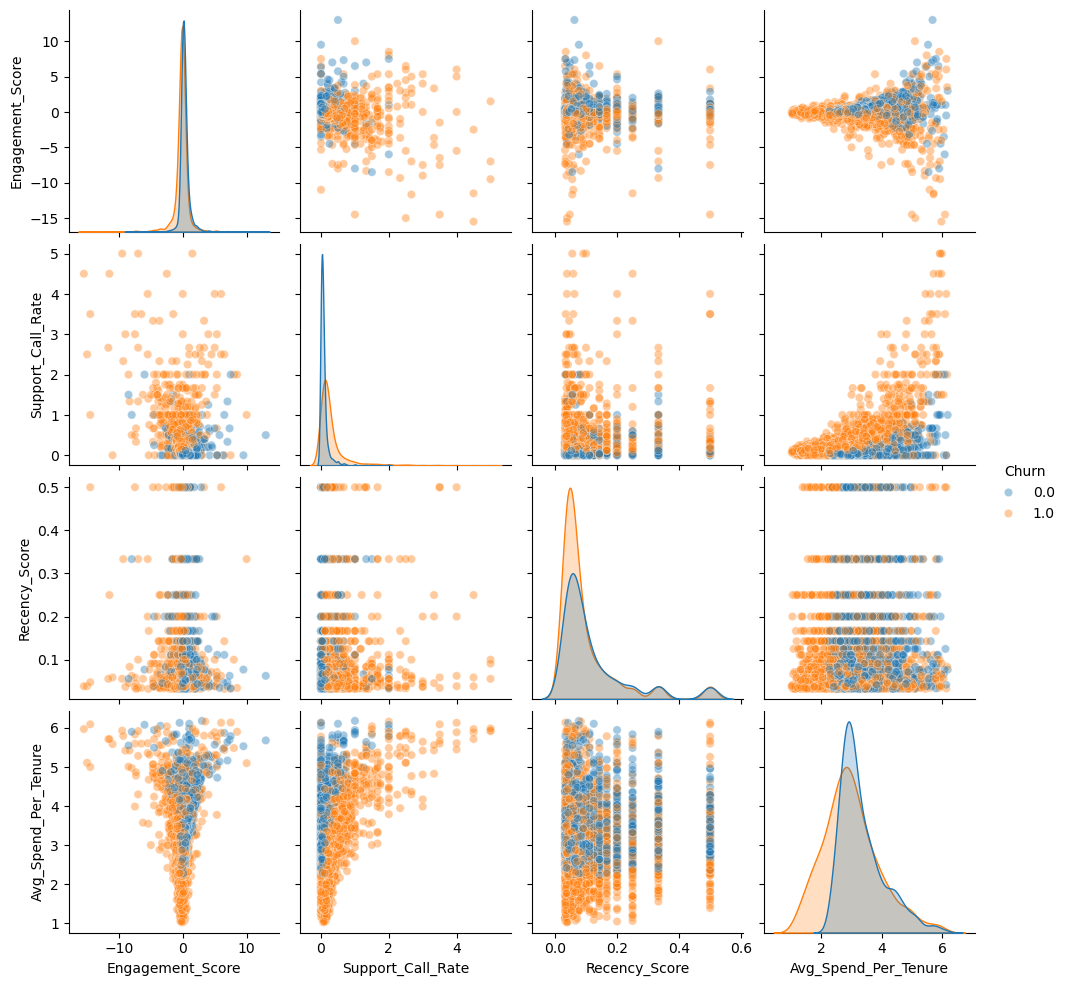

In [140]:
# Taking a 1% sample to keep it fast but representative
df_sample = df.sample(frac=0.01, random_state=42)

# Select the most interesting 4-5 features to avoid a messy 20x20 grid
pair_grid = sns.pairplot(df_sample,
                         vars=['Engagement_Score', 'Support_Call_Rate',
                               'Recency_Score', 'Avg_Spend_Per_Tenure'],
                         hue='Churn',
                         plot_kws={'alpha': 0.4})

# Save the figure to your working directory
pair_grid.savefig('pairplot_engineered_features.png', dpi=300, bbox_inches='tight')

plt.show()

## Statistical Tests & Model Setup

In [32]:
from scipy.stats import chi2_contingency

# Testing if Contract Length is significantly related to Churn
contingency_table = pd.crosstab(df['Contract Length_Monthly'], df['Churn'])
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value for Contract Length: {p:.4e}")

Chi-Square Statistic: 82860.1016
P-value for Contract Length: 0.0000e+00


In [33]:
from scipy.stats import mannwhitneyu

feature = 'Support_Call_Rate'
churn_group = df[df['Churn'] == 1][feature]
stay_group = df[df['Churn'] == 0][feature]

stat, p = mannwhitneyu(churn_group, stay_group)
print(f'Mann-Whitney U Test for {feature}: Statistics={stat:.3f}, p={p:.4e}')

Mann-Whitney U Test for Support_Call_Rate: Statistics=36717994094.500, p=0.0000e+00


In [34]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps churn ratio balanced
)

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps churn ratio balanced
)

In [36]:
num_cols = [
    'Avg_Spend_Per_Tenure',
    'Usage_Per_Tenure',
    'Support_Call_Rate',
    'Payment_Delay_Rate',
    'Recency_Score',
    'Engagement_Score'
]

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Select only numerical features
numeric_df = X_train.select_dtypes(include=[np.number])
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_df.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_df.values, i) 
                   for i in range(len(numeric_df.columns))]
print(vif_data.sort_values(by="VIF", ascending=False))

                feature        VIF
1      Usage_Per_Tenure  11.956812
3    Payment_Delay_Rate  11.136959
0  Avg_Spend_Per_Tenure   6.733907
5      Engagement_Score   3.118636
2     Support_Call_Rate   2.785612
4         Recency_Score   1.981058
6             High_Risk   1.631465


In [38]:
from sklearn.feature_selection import f_classif
# Calculate F-values and P-values
f_values, p_values = f_classif(X_train, y_train)

# Create a summary table
f_test_df = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Score': f_values,
    'P-Value': p_values
}).sort_values(by='F-Score', ascending=False)
print(f_test_df.head(10))

                      Feature       F-Score  P-Value
10    Contract Length_Monthly  81912.613174      0.0
6                   High_Risk  71094.834222      0.0
15            Age_Group_56-65  42555.350036      0.0
2           Support_Call_Rate  26979.972745      0.0
5            Engagement_Score  17964.107330      0.0
3          Payment_Delay_Rate  15149.305914      0.0
0        Avg_Spend_Per_Tenure  13050.270470      0.0
11  Contract Length_Quarterly  11427.285168      0.0
7                 Gender_Male  11081.138604      0.0
13            Age_Group_36-45  10599.853393      0.0


In [39]:
num_cols = [
    'Avg_Spend_Per_Tenure', 'Usage_Per_Tenure', 'Support_Call_Rate',
    'Payment_Delay_Rate',  'Recency_Score',    'Engagement_Score'
]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

bool_cols = X_train.select_dtypes(include=['bool']).columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [40]:
bool_cols = X_train.select_dtypes(include=['bool']).columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [41]:
X_train.dtypes

Avg_Spend_Per_Tenure          float64
Usage_Per_Tenure              float64
Support_Call_Rate             float64
Payment_Delay_Rate            float64
Recency_Score                 float64
Engagement_Score              float64
High_Risk                       int64
Gender_Male                     int64
Subscription Type_Premium       int64
Subscription Type_Standard      int64
Contract Length_Monthly         int64
Contract Length_Quarterly       int64
Age_Group_26-35                 int64
Age_Group_36-45                 int64
Age_Group_46-55                 int64
Age_Group_56-65                 int64
Age_Group_65+                   int64
dtype: object

## Model 1: Initial Logistic Baseline

In [42]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)

logm1 = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial())
result = logm1.fit()

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Churn   No. Observations:               352665
Model:                            GLM   Df Residuals:                   352648
Model Family:                Binomial   Df Model:                           16
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -95163.
Date:                Fri, 19 Jun 2026   Deviance:                   1.9033e+05
Time:                        15:13:43   Pearson chi2:                 1.66e+09
No. Iterations:                    31   Pseudo R-squ. (CS):             0.5633
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [43]:
X_test_sm1 = sm.add_constant(X_test)   # use original X_test before dropping Recency

y_pred_prob1 = result.predict(X_test_sm1)
y_pred1 = (y_pred_prob1 > 0.5).astype(int)

In [44]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

acc1 = accuracy_score(y_test, y_pred1)
roc1 = roc_auc_score(y_test, y_pred_prob1)

print("Model 1 (With Recency)")
print("Accuracy:", acc1)
print("ROC-AUC:", roc1)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))

Model 1 (With Recency)
Accuracy: 0.8948245942359386
ROC-AUC: 0.9521526019860088
Confusion Matrix:
 [[35463  2704]
 [ 6569 43431]]


In [45]:
# This model achieved high accuracy (89%) but exhibited Quasi-Complete Separation. The extreme coefficients (34.7) and massive standard errors
# indicate that the model was over-fitting to specific categorical boundaries, making it numerically unstable.

# Model 2: Optimized & Regularized Baseline

In [46]:
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# 1. Drop the columns that are breaking the math
cols_to_exclude = ['Contract Length_Monthly', 'Age_Group_56-65']
X_train_clean = X_train.drop(columns=cols_to_exclude)
X_test_clean = X_test.drop(columns=cols_to_exclude)

# 2. Fit the statsmodels GLM to see the P-values and Stable Coefficients
X_train_sm = sm.add_constant(X_train_clean)
sm_model = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial()).fit()

# 3. Print the Summary Table
print(sm_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Churn   No. Observations:               352665
Model:                            GLM   Df Residuals:                   352650
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.3611e+05
Date:                Fri, 19 Jun 2026   Deviance:                   2.7223e+05
Time:                        15:13:48   Pearson chi2:                 1.39e+09
No. Iterations:                     8   Pseudo R-squ. (CS):             0.4492
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [47]:
# 4. Find Accuracy and ROC-AUC
# We use the test set to see how it generalizes
X_test_sm = sm.add_constant(X_test_clean)
y_prob = sm_model.predict(X_test_sm)
y_pred = (y_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\n--- PERFORMANCE METRICS ---")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {roc:.4f}")

# 5. Confusion Matrix to check False Negatives
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


--- PERFORMANCE METRICS ---
Accuracy: 0.8338
ROC-AUC:  0.9072

Confusion Matrix:
[[31706  6461]
 [ 8196 41804]]


In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Prepare the data (VIF needs the constant/intercept column)
X_vif = sm.add_constant(X_train_clean)

# 2. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# 3. Display sorted results
print("--- VIF Check (Cleaned Dataset) ---")
display(vif_data.sort_values(by="VIF", ascending=False))

--- VIF Check (Cleaned Dataset) ---


,Feature,VIF
0,const,7.889346
2,Usage_Per_Tenure,5.227482
4,Payment_Delay_Rate,4.023584
6,Engagement_Score,3.122995
1,Avg_Spend_Per_Tenure,2.324400
3,Support_Call_Rate,2.280022
13,Age_Group_36-45,1.427344
7,High_Risk,1.400736
12,Age_Group_26-35,1.398823
14,Age_Group_46-55,1.359428


# Model 3: Logistic Regression 

In [49]:
y_test_pred_final = pd.DataFrame({
    "Churn": y_test,
    "Churn_Prob": y_prob
})

In [50]:
print(y_test_pred_final.head())

        Churn  Churn_Prob
30086     1.0    0.990930
368225    0.0    0.093310
146939    1.0    0.427023
368276    0.0    0.049528
153765    1.0    0.376408


In [51]:
from sklearn import metrics
import matplotlib.pyplot as plt

def draw_roc(actual, probs):
    fpr, tpr, thresholds = metrics.roc_curve(actual, probs)
    auc_score = metrics.roc_auc_score(actual, probs)

    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % auc_score)
    plt.plot([0,1], [0,1], 'k--')
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Logistic Regression')
    plt.legend(loc="lower right")
    plt.show()

    return auc_score

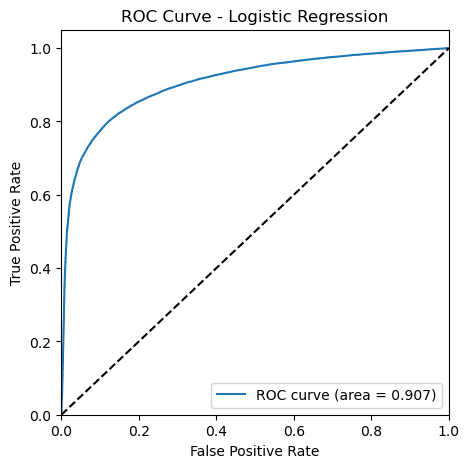

0.9071855346241517

In [52]:
draw_roc(y_test_pred_final.Churn, y_test_pred_final.Churn_Prob)

In [53]:
cutoff_df = pd.DataFrame(columns=['prob','accuracy','sensi','speci'])

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

for i in num:
    y_test_pred_final[i] = y_test_pred_final.Churn_Prob.map(lambda x: 1 if x > i else 0)

    cm = metrics.confusion_matrix(y_test_pred_final.Churn,
                                  y_test_pred_final[i])

    total = sum(sum(cm))

    accuracy = (cm[0,0] + cm[1,1]) / total
    speci = cm[0,0] / (cm[0,0] + cm[0,1])
    sensi = cm[1,1] / (cm[1,0] + cm[1,1])

    cutoff_df.loc[i] = [i, accuracy, sensi, speci]

cutoff_df

,prob,accuracy,sensi,speci
0.0,0.0,0.567106,1.00000,0.000000
0.1,0.1,0.656209,0.98234,0.228967
0.2,0.2,0.739562,0.95622,0.455734
0.3,0.3,0.791521,0.92072,0.622265
0.4,0.4,0.821192,0.88128,0.742474
0.5,0.5,0.833759,0.83608,0.830718
0.6,0.6,0.830696,0.78266,0.893625
0.7,0.7,0.813263,0.71810,0.937931
0.8,0.8,0.778976,0.63514,0.967406
0.9,0.9,0.713759,0.50684,0.984830


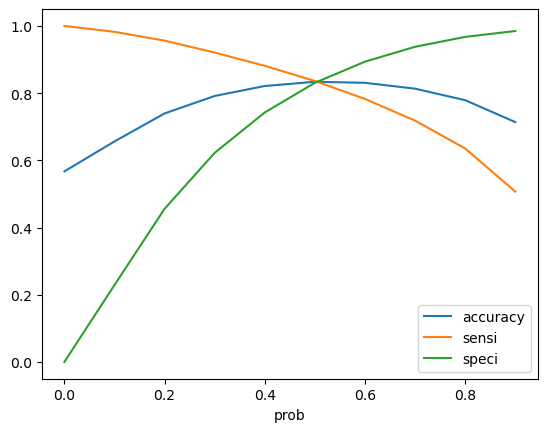

In [54]:
cutoff_df.plot.line(x='prob', y=['accuracy','sensi','speci'])
plt.show()

In [55]:
# Get predicted probabilities from test set
y_pred_prob = sm_model.predict(X_test_sm)   # statsmodels GLM

In [56]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", roc_score)

ROC-AUC: 0.9071855346241517


In [57]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob)

youden_index = tpr - fpr
optimal_index = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_index]

print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.5710811115452762


In [58]:
from sklearn import metrics
import numpy as np

y_pred_prob = sm_model.predict(X_test_sm)
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob)

youden_index = tpr - fpr
optimal_index = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_index]

y_pred_optimal = (y_pred_prob >= optimal_threshold).astype(int)

In [59]:
y_pred_optimal = (y_pred_prob >= optimal_threshold).astype(int)

In [60]:
accuracy_opt = accuracy_score(y_test, y_pred_optimal)
cm_opt = confusion_matrix(y_test, y_pred_optimal)

print("Model 3 (Optimal Threshold)")
print("Accuracy:", accuracy_opt)
print("ROC-AUC:", roc_score)  # same as before
print("Confusion Matrix:\n", cm_opt)

Model 3 (Optimal Threshold)
Accuracy: 0.8338947678836753
ROC-AUC: 0.9071855346241517
Confusion Matrix:
 [[33493  4674]
 [ 9971 40029]]


## Doing K cross Validation for Logistic Regression 

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np
import time

# Initialize LR using raw X_train
lr_unscaled = LogisticRegression(max_iter=1000, random_state=42)

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import time

lr_unscaled = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
cv_scores_lr = cross_val_score(lr_unscaled, X_train, y_train, cv=5, n_jobs=-1)
end_time = time.time()

In [63]:
print("Starting 5-Fold Cross-Validation for Logistic Regression...")
start_time = time.time()

cv_scores_lr_raw = cross_val_score(lr_unscaled, X_train, y_train, cv=5, n_jobs=-1)

end_time = time.time()


Starting 5-Fold Cross-Validation for Logistic Regression...


In [64]:
print(f"--- Results ---")
print(f"Individual Fold Accuracies: {cv_scores_lr_raw}")
print(f"Mean CV Accuracy: {cv_scores_lr_raw.mean():.4f}")
print(f"Standard Deviation: {cv_scores_lr_raw.std():.4f}")
print(f"Time Taken: {end_time - start_time:.2f} seconds")

--- Results ---
Individual Fold Accuracies: [0.89833128 0.89726795 0.89692768 0.89498533 0.89918194]
Mean CV Accuracy: 0.8973
Standard Deviation: 0.0014
Time Taken: 10.88 seconds


# Random Forest Classifier

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Initialize model
rf = RandomForestClassifier(
    n_estimators=100,      
    max_depth=12,         
    min_samples_split=100, 
    min_samples_leaf=50,   
    max_features='sqrt',   
    random_state=100,
    n_jobs=-1              # Use all CPU cores for speed
)


In [66]:
# Fit model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_prob_rf = rf.predict_proba(X_test)[:, 1]

In [67]:
# Evaluation
acc_rf = accuracy_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_pred_prob_rf)

print("Random Forest Results")
print("Accuracy:", acc_rf)
print("ROC-AUC:", roc_rf)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9499812855149886
ROC-AUC: 0.9847145395236723
Confusion Matrix:
 [[37162  1005]
 [ 3405 46595]]


In [68]:
print(f"Training Accuracy: {rf.score(X_train, y_train):.4f}")
print(f"Test Accuracy:     {rf.score(X_test, y_test):.4f}")

Training Accuracy: 0.9530
Test Accuracy:     0.9500


In [69]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
2,Support_Call_Rate,0.216177
10,Contract Length_Monthly,0.195776
0,Avg_Spend_Per_Tenure,0.175076
15,Age_Group_56-65,0.100114
6,High_Risk,0.094493
5,Engagement_Score,0.058849
4,Recency_Score,0.049405
7,Gender_Male,0.043295
3,Payment_Delay_Rate,0.027732
1,Usage_Per_Tenure,0.015178


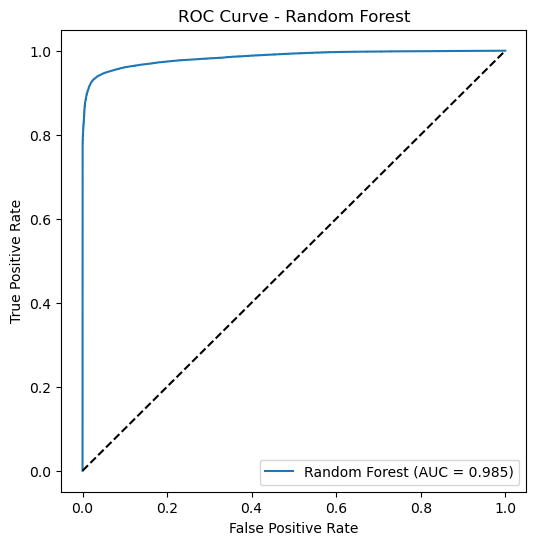

In [70]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
auc_score = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [71]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94     38167
         1.0       0.98      0.93      0.95     50000

    accuracy                           0.95     88167
   macro avg       0.95      0.95      0.95     88167
weighted avg       0.95      0.95      0.95     88167



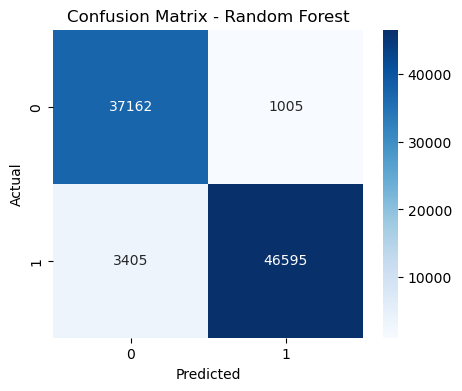

In [72]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

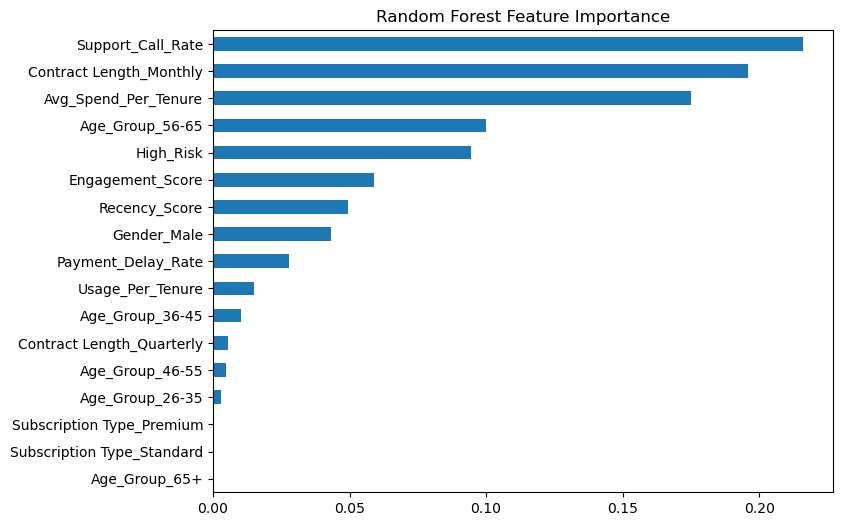

In [73]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(8,6))
importance.plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.show()

In [158]:
import pandas as pd

rf_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest — Top 15 Features by Importance:")
print(rf_importance.head(15).to_string(index=False))

Random Forest — Top 15 Features by Importance:
                  Feature  Importance
        Support_Call_Rate    0.216177
  Contract Length_Monthly    0.195776
     Avg_Spend_Per_Tenure    0.175076
          Age_Group_56-65    0.100114
                High_Risk    0.094493
         Engagement_Score    0.058849
            Recency_Score    0.049405
              Gender_Male    0.043295
       Payment_Delay_Rate    0.027732
         Usage_Per_Tenure    0.015178
          Age_Group_36-45    0.010271
Contract Length_Quarterly    0.005335
          Age_Group_46-55    0.004745
          Age_Group_26-35    0.002805
Subscription Type_Premium    0.000380


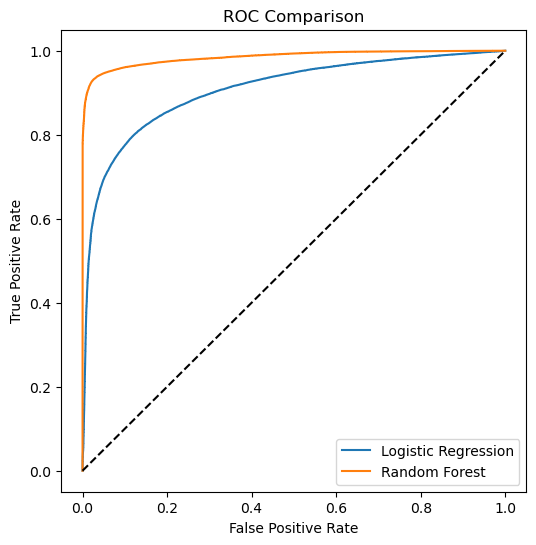

In [74]:
# Logistic probabilities
y_prob_log = sm_model.predict(X_test_sm)

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.show()

## Cross-Validation: Random Forest

In [75]:
from sklearn.ensemble import RandomForestClassifier
import time

# We use 100 trees (n_estimators) as a standard research baseline
rf_cv = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

print("Starting 5-Fold Cross-Validation for Random Forest...")
start_time = time.time()

cv_scores_rf = cross_val_score(rf_cv, X_train, y_train, cv=5, n_jobs=1)

print(f"--- Random Forest Results ---")
print(f"Mean CV Accuracy: {cv_scores_rf.mean():.4f}")
print(f"Standard Deviation: {cv_scores_rf.std():.4f}")
print(f"Total Time: {(time.time() - start_time)/60:.2f} minutes")

Starting 5-Fold Cross-Validation for Random Forest...
--- Random Forest Results ---
Mean CV Accuracy: 0.9466
Standard Deviation: 0.0013
Total Time: 5.34 minutes


# Plot to show why Random Forest does better than Logistic Regression

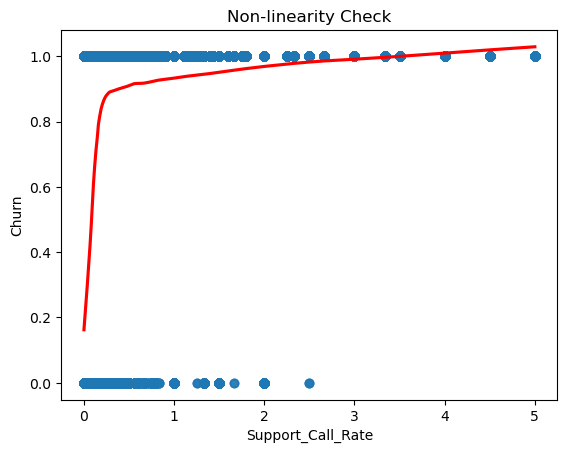

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    x="Support_Call_Rate",
    y="Churn",
    data=df,
    lowess=True,
    scatter_kws={'alpha':0.2},
    line_kws={'color':'red'}
)

plt.title("Non-linearity Check")
plt.show()

In [77]:
# The LOWESS smoothing curve demonstrates a nonlinear relationship between customer behavioral variables and churn probability, 
# violating the linearity assumption required by logistic regression

# Decision Trees Classifier

In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Create model
dt_model = DecisionTreeClassifier(
    max_depth=5,        # prevents overfitting
    random_state=42
)

# Train
dt_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [79]:
# Predict
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.8901403019270249
ROC-AUC: 0.937430541829329
              precision    recall  f1-score   support

         0.0       0.82      0.96      0.88     38167
         1.0       0.97      0.83      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.90      0.89     88167
weighted avg       0.90      0.89      0.89     88167



# Decision Tree 2nd Model

In [80]:
dt_model_2 = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

In [81]:
# Train
dt_model_2.fit(X_train, y_train)
# Predict
y_pred = dt_model_2.predict(X_test)
y_prob = dt_model_2.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.901164834915558
ROC-AUC: 0.9480788791364267
              precision    recall  f1-score   support

         0.0       0.84      0.96      0.89     38167
         1.0       0.96      0.86      0.91     50000

    accuracy                           0.90     88167
   macro avg       0.90      0.91      0.90     88167
weighted avg       0.91      0.90      0.90     88167



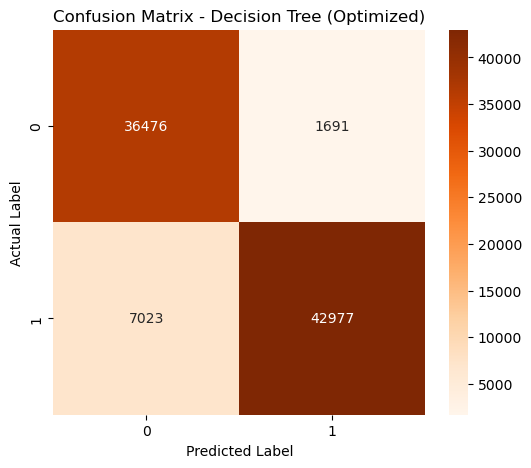

In [82]:
cm_dt = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges') 
plt.title('Confusion Matrix - Decision Tree (Optimized)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [83]:
importance = pd.Series(
    dt_model_2.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

Support_Call_Rate             0.394661
Contract Length_Monthly       0.241961
Avg_Spend_Per_Tenure          0.226655
Age_Group_56-65               0.100464
Engagement_Score              0.019615
High_Risk                     0.008510
Payment_Delay_Rate            0.008134
Contract Length_Quarterly     0.000000
Age_Group_46-55               0.000000
Age_Group_36-45               0.000000
Age_Group_26-35               0.000000
Subscription Type_Premium     0.000000
Subscription Type_Standard    0.000000
Usage_Per_Tenure              0.000000
Gender_Male                   0.000000
Recency_Score                 0.000000
Age_Group_65+                 0.000000
dtype: float64


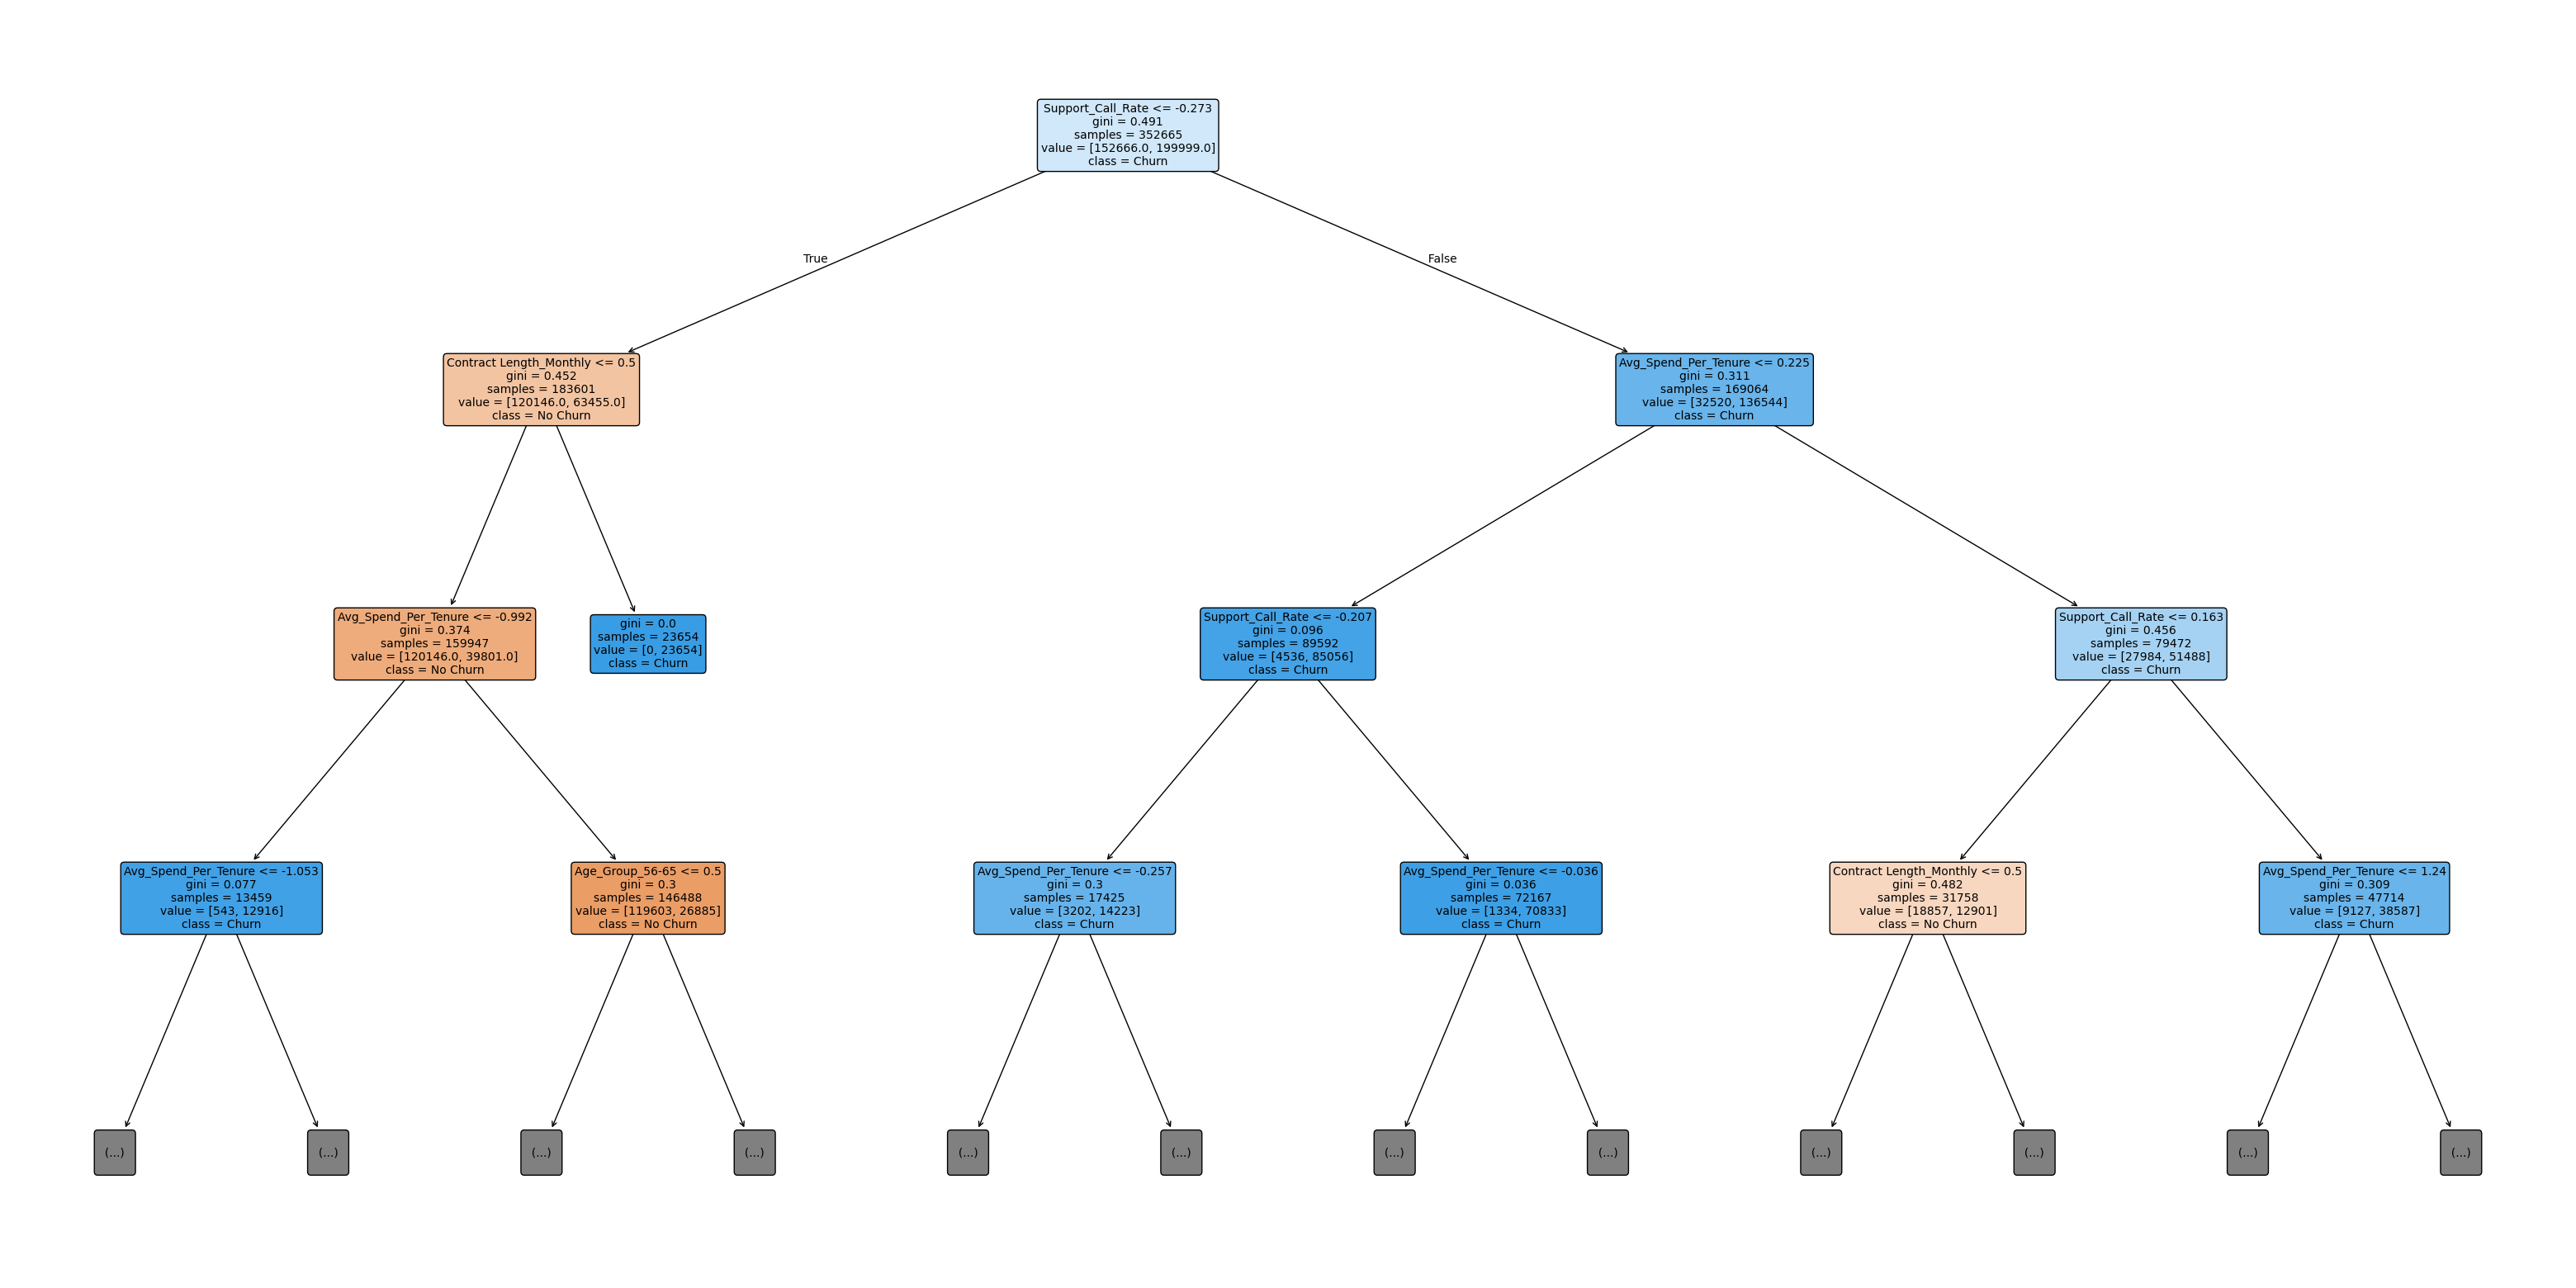

In [84]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40,20))   # increase size

plot_tree(
    dt_model_2,
    feature_names=X_train.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

In [85]:
from sklearn.metrics import accuracy_score

train_pred = dt_model_2.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 0.9036677867097671
Test Accuracy: 0.901164834915558


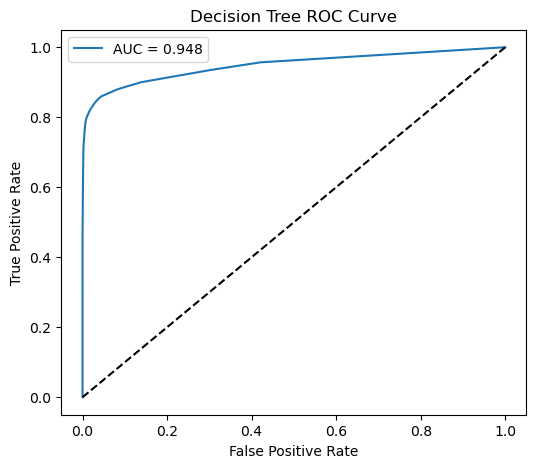

In [86]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

## K CROSS VALIDATION ON DECISION TREE

In [87]:
from sklearn.tree import DecisionTreeClassifier
import time

dt_cv = DecisionTreeClassifier(max_depth=10, random_state=42)

print("Starting 5-Fold Cross-Validation for Decision Tree...")
start_time = time.time()

# Using raw X_train
cv_scores_dt = cross_val_score(dt_cv, X_train, y_train, cv=5, n_jobs=-1)

print(f"--- Results ---")
print(f"Mean CV Accuracy: {cv_scores_dt.mean():.4f}")
print(f"Standard Deviation: {cv_scores_dt.std():.4f}")
print(f"Time Taken: {time.time() - start_time:.2f} seconds")

Starting 5-Fold Cross-Validation for Decision Tree...
--- Results ---
Mean CV Accuracy: 0.9427
Standard Deviation: 0.0002
Time Taken: 6.45 seconds


## Gradient Boosting Classifier

In [88]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [89]:
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Results
Accuracy: 0.9507185228033165
ROC-AUC: 0.985575287028061
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94     38167
         1.0       0.98      0.93      0.96     50000

    accuracy                           0.95     88167
   macro avg       0.95      0.95      0.95     88167
weighted avg       0.95      0.95      0.95     88167



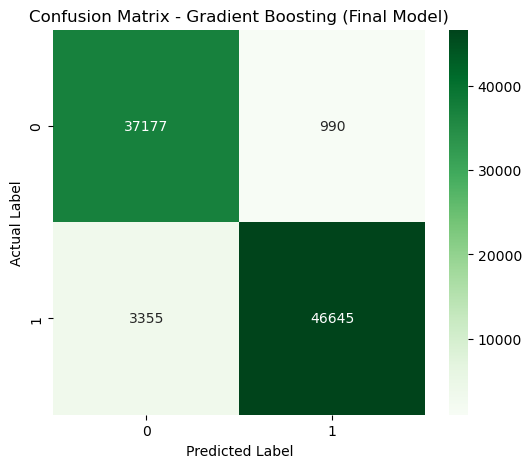

In [90]:
# Generate the matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)

# Plotting
plt.figure(figsize=(6,5))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens') # Green for the final winner!
plt.title('Confusion Matrix - Gradient Boosting (Final Model)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [91]:
log_prob = y_test_pred_final.Churn_Prob
dt_prob = dt_model_2.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]

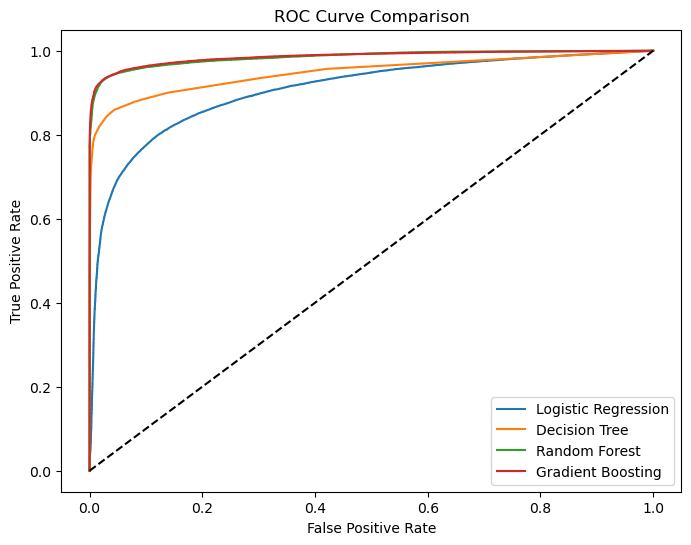

In [92]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": log_prob,
    "Decision Tree": dt_prob,
    "Random Forest": rf_prob,
    "Gradient Boosting": gb_prob
}

for name, prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [93]:
importance = pd.Series(
    gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

Support_Call_Rate             0.330388
Contract Length_Monthly       0.223334
Avg_Spend_Per_Tenure          0.199658
Age_Group_56-65               0.098280
High_Risk                     0.046435
Engagement_Score              0.030628
Recency_Score                 0.024024
Payment_Delay_Rate            0.020916
Gender_Male                   0.018119
Age_Group_36-45               0.005558
Age_Group_46-55               0.001918
Age_Group_26-35               0.000377
Usage_Per_Tenure              0.000365
Subscription Type_Premium     0.000000
Contract Length_Quarterly     0.000000
Subscription Type_Standard    0.000000
Age_Group_65+                 0.000000
dtype: float64


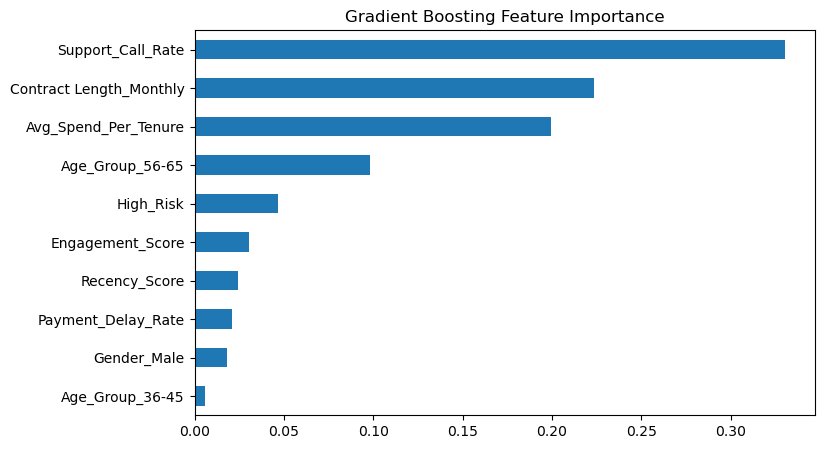

In [94]:
import matplotlib.pyplot as plt

importance.head(10).plot(kind="barh", figsize=(8,5))
plt.title("Gradient Boosting Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [157]:
gb_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': gb_model_2.feature_importances_
}).sort_values('Importance', ascending=False)

print("Gradient Boosting — Top 15 Features by Importance:")
print(gb_importance.head(15).to_string(index=False))

Gradient Boosting — Top 15 Features by Importance:
                  Feature  Importance
        Support_Call_Rate    0.329120
  Contract Length_Monthly    0.223074
     Avg_Spend_Per_Tenure    0.200019
          Age_Group_56-65    0.097910
                High_Risk    0.046758
         Engagement_Score    0.030404
            Recency_Score    0.027233
       Payment_Delay_Rate    0.021942
              Gender_Male    0.015613
          Age_Group_36-45    0.005452
          Age_Group_46-55    0.001736
          Age_Group_26-35    0.000453
         Usage_Per_Tenure    0.000286
Subscription Type_Premium    0.000000
Contract Length_Quarterly    0.000000


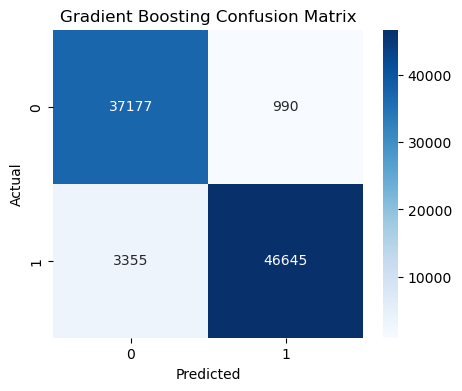

In [95]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

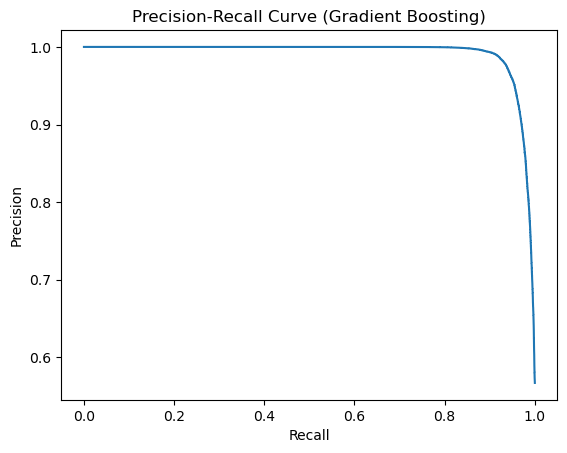

In [96]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, gb_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Gradient Boosting)")
plt.show()

# Hyperparamater Tuning- Gradient Boosting 

In [97]:
gb_model_2 = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb_model_2.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,200
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [98]:
y_pred_gb = gb_model_2.predict(X_test)
y_prob_gb = gb_model_2.predict_proba(X_test)[:,1]

print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Results
Accuracy: 0.9506051016820353
ROC-AUC: 0.9855396232347315
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94     38167
         1.0       0.98      0.93      0.96     50000

    accuracy                           0.95     88167
   macro avg       0.95      0.95      0.95     88167
weighted avg       0.95      0.95      0.95     88167



In [99]:
print("Train Accuracy:", gb_model_2.score(X_train, y_train))
print("Test Accuracy:", gb_model_2.score(X_test, y_test))

Train Accuracy: 0.9523570527270923
Test Accuracy: 0.9506051016820353


## Cross Validation on Gradient Boosting

In [100]:
from sklearn.ensemble import GradientBoostingClassifier
import time

# Standard research parameters
gb_cv = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

print("Starting 5-Fold Cross-Validation for Gradient Boosting...")
start_time = time.time()

# Staying with n_jobs=1 for system safety
cv_scores_gb = cross_val_score(gb_cv, X_train, y_train, cv=5, n_jobs=1)

print(f"--- Gradient Boosting Results ---")
print(f"Mean CV Accuracy: {cv_scores_gb.mean():.4f}")
print(f"Standard Deviation: {cv_scores_gb.std():.4f}")
print(f"Total Time: {(time.time() - start_time)/60:.2f} minutes")

Starting 5-Fold Cross-Validation for Gradient Boosting...
--- Gradient Boosting Results ---
Mean CV Accuracy: 0.9607
Standard Deviation: 0.0007
Total Time: 6.10 minutes


# KNN Classifier

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_knn = scaler.fit_transform(X_train)
X_test_knn = scaler.transform(X_test)

In [102]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_knn, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [103]:
y_pred_knn = knn.predict(X_test_knn)
y_prob_knn = knn.predict_proba(X_test_knn)[:,1]

In [104]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("KNN Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Results
Accuracy: 0.926389692288498
ROC-AUC: 0.9688463444860744
[[37056  1111]
 [ 5379 44621]]
              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92     38167
         1.0       0.98      0.89      0.93     50000

    accuracy                           0.93     88167
   macro avg       0.92      0.93      0.93     88167
weighted avg       0.93      0.93      0.93     88167



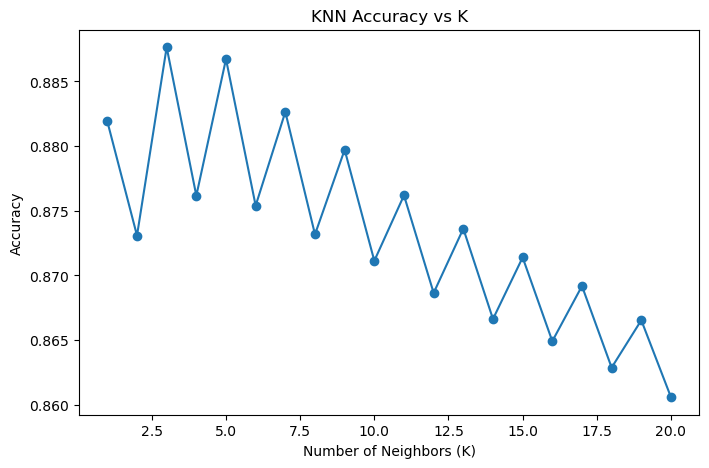

In [105]:
import matplotlib.pyplot as plt
import numpy as np

k_values = range(1,21)
accuracy_scores = []
X_train_sample = X_train_knn[:30000] 
y_train_sample = y_train[:30000]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_sample, y_train_sample)
    pred = knn.predict(X_test_knn)
    accuracy_scores.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()

## Hyperparameter Tuning on KNN with k=3 for better results

In [106]:
from sklearn.neighbors import KNeighborsClassifier
knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(X_train_knn, y_train)
y_pred_knn_2 = knn2.predict(X_test_knn)
y_prob_knn_2 = knn2.predict_proba(X_test_knn)[:,1]


In [107]:
y_pred_knn_2 = knn2.predict(X_test_knn)
y_prob_knn_2 = knn2.predict_proba(X_test_knn)[:,1]

In [108]:
print("KNN Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_2))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn_2))

print(confusion_matrix(y_test, y_pred_knn_2))
print(classification_report(y_test, y_pred_knn_2))

KNN Results
Accuracy: 0.9266505608674447
ROC-AUC: 0.9614626957843162
[[36714  1453]
 [ 5014 44986]]
              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92     38167
         1.0       0.97      0.90      0.93     50000

    accuracy                           0.93     88167
   macro avg       0.92      0.93      0.93     88167
weighted avg       0.93      0.93      0.93     88167



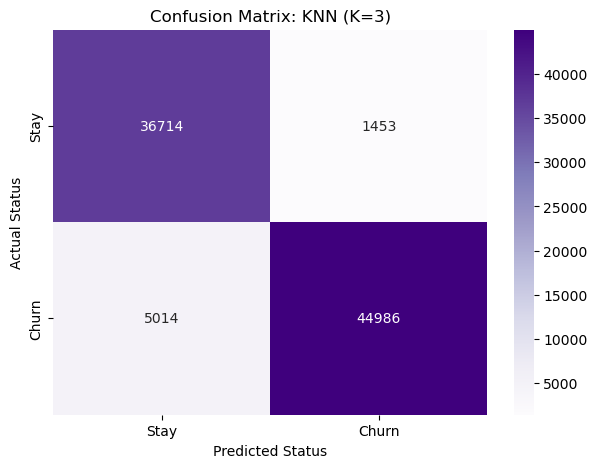

In [109]:
# Generate the matrix using your new K=3 predictions
cm_knn = confusion_matrix(y_test, y_pred_knn_2)

# Plotting the Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Stay', 'Churn'], 
            yticklabels=['Stay', 'Churn'])

plt.title('Confusion Matrix: KNN (K=3)')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()

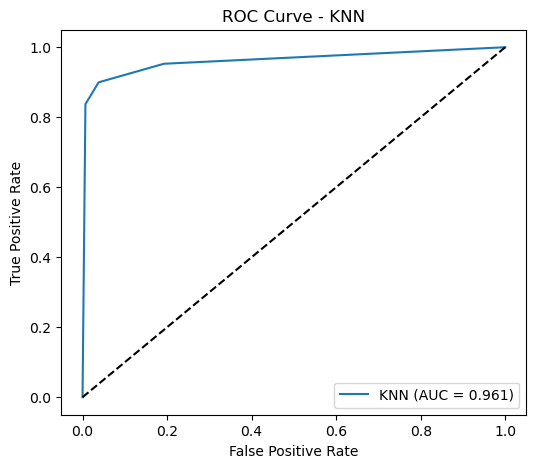

In [110]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Fixed variable name: y_prob_knn_2
fpr, tpr, _ = roc_curve(y_test, y_prob_knn_2)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="KNN (AUC = %.3f)" % roc_auc_score(y_test, y_prob_knn_2))
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()

In [111]:
# The optimal value of K was selected using validation accuracy analysis. The model achieved maximum performance at K = 3, 
# beyond which accuracy started decreasing due to increased bias.

In [147]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import time

knn_cv = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)

start_time = time.time()
# Use a sample for tractability; full CV on 352,665 with KNN is slow
cv_scores_knn = cross_val_score(knn_cv, X_train_knn[:50000], y_train[:50000],
                                 cv=5, n_jobs=1)
elapsed = (time.time() - start_time) / 60

print(f"KNN 5-Fold CV mean: {cv_scores_knn.mean():.4f}")
print(f"KNN 5-Fold CV std:  {cv_scores_knn.std():.4f}")
print(f"Per-fold scores:    {cv_scores_knn}")
print(f"Time: {elapsed:.2f} minutes")

KNN 5-Fold CV mean: 0.8970
KNN 5-Fold CV std:  0.0022
Per-fold scores:    [0.896  0.899  0.8939 0.8962 0.9001]
Time: 0.06 minutes


## Gaussian Naive Bayes Classifier

In [112]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

nb = GaussianNB()

In [113]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

In [114]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7289575464743044
ROC-AUC: 0.9099460285063012
              precision    recall  f1-score   support

         0.0       0.62      0.99      0.76     38167
         1.0       0.99      0.53      0.69     50000

    accuracy                           0.73     88167
   macro avg       0.80      0.76      0.72     88167
weighted avg       0.83      0.73      0.72     88167



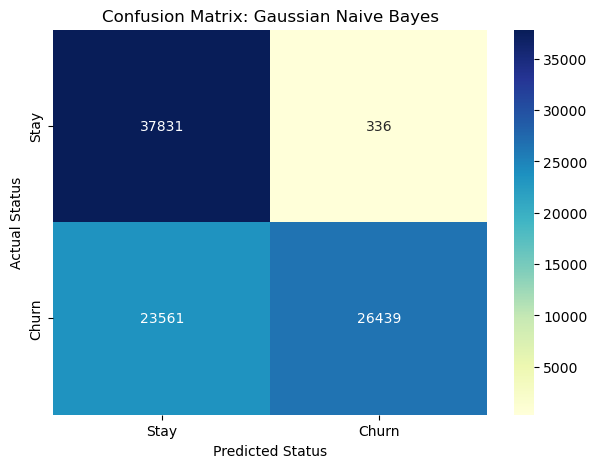

In [115]:
# Generate the matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plotting
plt.figure(figsize=(7,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Stay', 'Churn'], 
            yticklabels=['Stay', 'Churn'])

plt.title('Confusion Matrix: Gaussian Naive Bayes')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()

## K Cross Validation on Naive Bayes

In [116]:
from sklearn.naive_bayes import GaussianNB
import time

nb_cv = GaussianNB()

print("Starting 5-Fold Cross-Validation for Naive Bayes...")
start_time = time.time()

cv_scores_nb = cross_val_score(nb_cv, X_train_knn, y_train, cv=5, n_jobs=-1)

print(f"--- Results ---")
print(f"Mean CV Accuracy: {cv_scores_nb.mean():.4f}")
print(f"Standard Deviation: {cv_scores_nb.std():.4f}")
print(f"Time Taken: {time.time() - start_time:.2f} seconds")

Starting 5-Fold Cross-Validation for Naive Bayes...
--- Results ---
Mean CV Accuracy: 0.7312
Standard Deviation: 0.0016
Time Taken: 4.86 seconds


In [117]:
from sklearn.naive_bayes import GaussianNB
import time

# Initialize
nb_unscaled_cv = GaussianNB()

print("Starting 5-Fold Cross-Validation for Naive Bayes (UNSCALED)...")
start_time = time.time()

# Note: Using X_train (raw) instead of X_train_knn (scaled)
cv_scores_nb_raw = cross_val_score(nb_unscaled_cv, X_train, y_train, cv=5, n_jobs=-1)

print(f"--- Unscaled NB Results ---")
print(f"Mean CV Accuracy: {cv_scores_nb_raw.mean():.4f}")
print(f"Standard Deviation: {cv_scores_nb_raw.std():.4f}")
print(f"Time Taken: {time.time() - start_time:.2f} seconds")

Starting 5-Fold Cross-Validation for Naive Bayes (UNSCALED)...
--- Unscaled NB Results ---
Mean CV Accuracy: 0.7331
Standard Deviation: 0.0017
Time Taken: 4.29 seconds


In [118]:
from sklearn.naive_bayes import GaussianNB

nb_cv = GaussianNB()
cv_scores_nb = cross_val_score(nb_cv, X_train, y_train, cv=5, n_jobs=-1)

## MLPClassifier (Scikit-Learn)

In [119]:
from sklearn.neural_network import MLPClassifier

# Initializing a 3-layer network (100, 50, 25 neurons)
mlp = MLPClassifier(hidden_layer_sizes=(100, 50, 25), 
                    max_iter=300, 
                    activation='relu', 
                    solver='adam', 
                    random_state=42,
                    verbose=True) 


In [120]:
# using the SCALED data for Neural Networks
mlp.fit(X_train_knn, y_train)

y_pred_mlp = mlp.predict(X_test_knn)
y_prob_mlp = mlp.predict_proba(X_test_knn)[:,1]

Iteration 1, loss = 0.16707104
Iteration 2, loss = 0.12160205
Iteration 3, loss = 0.11286005
Iteration 4, loss = 0.10871652
Iteration 5, loss = 0.10609708
Iteration 6, loss = 0.10408537
Iteration 7, loss = 0.10244928
Iteration 8, loss = 0.10138924
Iteration 9, loss = 0.10042618
Iteration 10, loss = 0.09939101
Iteration 11, loss = 0.09911784
Iteration 12, loss = 0.09837299
Iteration 13, loss = 0.09814871
Iteration 14, loss = 0.09765113
Iteration 15, loss = 0.09714619
Iteration 16, loss = 0.09666964
Iteration 17, loss = 0.09637211
Iteration 18, loss = 0.09636167
Iteration 19, loss = 0.09568806
Iteration 20, loss = 0.09531863
Iteration 21, loss = 0.09505979
Iteration 22, loss = 0.09472995
Iteration 23, loss = 0.09472179
Iteration 24, loss = 0.09450961
Iteration 25, loss = 0.09414365
Iteration 26, loss = 0.09377450
Iteration 27, loss = 0.09352180
Iteration 28, loss = 0.09337400
Iteration 29, loss = 0.09314531
Iteration 30, loss = 0.09295761
Iteration 31, loss = 0.09266461
Iteration 32, los

In [150]:
print("MLP Results")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_mlp))
print("F1-Score:", f1_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

MLP Results
Accuracy: 0.9623668719588961
ROC-AUC: 0.9897831755181177
F1-Score: 0.966209748049779
              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96     38167
         1.0       0.98      0.95      0.97     50000

    accuracy                           0.96     88167
   macro avg       0.96      0.96      0.96     88167
weighted avg       0.96      0.96      0.96     88167



In [122]:
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier

# Define the model again
mlp_cv = MLPClassifier(hidden_layer_sizes=(100, 50, 25), max_iter=300, random_state=42)

# Perform 5-fold Cross-Validation
# This will split the data into 5 parts and train 5 times
cv_scores = cross_val_score(mlp_cv, X_train_knn, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-Validation Accuracy Scores: [0.96281173 0.95973516 0.96133725 0.96190436 0.94866233]
Mean CV Accuracy: 0.9588901648873577
Standard Deviation: 0.0052110444069675375


In [151]:
# Shallow MLP — full evaluation for Section 5.4
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score)

shallow_mlp = random_search.best_estimator_   # (100,) MLP
y_pred_shallow  = shallow_mlp.predict(X_test_knn)
y_prob_shallow  = shallow_mlp.predict_proba(X_test_knn)[:, 1]

print("Shallow MLP — Test Set Performance")
print(f"Accuracy : {accuracy_score(y_test, y_pred_shallow):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_shallow):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_shallow):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_shallow):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_shallow):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_shallow, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_shallow))

Shallow MLP — Test Set Performance
Accuracy : 0.9624
Precision: 0.9842
Recall   : 0.9490
F1-Score : 0.9663
ROC-AUC  : 0.9906

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9362    0.9801    0.9576     38167
         1.0     0.9842    0.9490    0.9663     50000

    accuracy                         0.9624     88167
   macro avg     0.9602    0.9645    0.9619     88167
weighted avg     0.9634    0.9624    0.9625     88167


Confusion Matrix:
[[37406   761]
 [ 2551 47449]]


In [152]:
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier

shallow_cv = MLPClassifier(hidden_layer_sizes=(100,),
                           max_iter=300, random_state=42)
cv_scores_shallow = cross_val_score(shallow_cv, X_train_knn, y_train,
                                    cv=5, scoring='accuracy')
print("Shallow MLP 5-Fold CV Scores:", cv_scores_shallow)
print(f"Mean: {cv_scores_shallow.mean():.4f}")
print(f"Std : {cv_scores_shallow.std():.4f}")

Shallow MLP 5-Fold CV Scores: [0.96336467 0.96208867 0.96247147 0.96339302 0.96339302]
Mean: 0.9629
Std : 0.0006


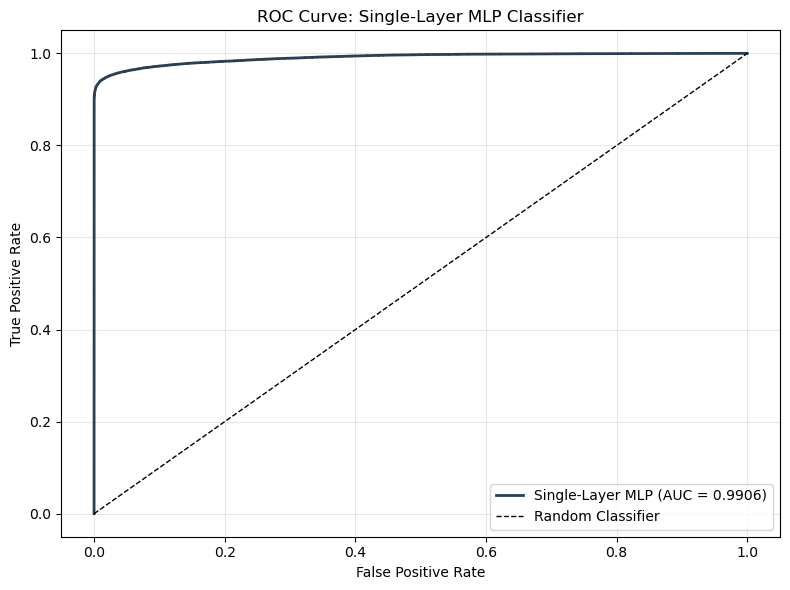

In [153]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr_shallow, tpr_shallow, _ = roc_curve(y_test, y_prob_shallow)
auc_shallow = roc_auc_score(y_test, y_prob_shallow)

plt.figure(figsize=(8, 6))
plt.plot(fpr_shallow, tpr_shallow,
         label=f'Single-Layer MLP (AUC = {auc_shallow:.4f})',
         linewidth=2, color='#2c3e50')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Single-Layer MLP Classifier')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure_5_2_roc_shallow_mlp.png', dpi=300, bbox_inches='tight')
plt.show()

In [160]:
import os
import tempfile

d_drive_temp = "D:\\PythonTemp"
if not os.path.exists(d_drive_temp):
    os.makedirs(d_drive_temp)

os.environ['JOBLIB_TEMP_FOLDER'] = d_drive_temp
tempfile.tempdir = d_drive_temp

print(f"Temporary workspace moved to D: drive")

Temporary workspace moved to D: drive


In [124]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

# A focused search space to get you a result quickly
param_dist = {
    'hidden_layer_sizes': [(100, 50, 25), (100,)], 
    'activation': ['relu'],
    'alpha': [0.0001]
}

# n_jobs=1 ensures stability on a tight system
mlp_search = MLPClassifier(max_iter=300, random_state=42)

random_search = RandomizedSearchCV(mlp_search, param_dist, 
                                   n_iter=2, cv=3, n_jobs=1, 
                                   verbose=2, random_state=42)

print("Starting MLP Optimization on D: Drive...")
random_search.fit(X_train_knn, y_train)

print(f"\nBest Architecture: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_:.4f}")

Starting MLP Optimization on D: Drive...
ERROR! Session/line number was not unique in database. History logging moved to new session 45
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100, 50, 25); total time= 9.5min
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100, 50, 25); total time= 9.2min
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100, 50, 25); total time= 9.2min
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100,); total time= 1.7min
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100,); total time= 1.5min
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(100,); total time= 2.1min

Best Architecture: {'hidden_layer_sizes': (100,), 'alpha': 0.0001, 'activation': 'relu'}
Best Score: 0.9626


In [148]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred_mlp))

[[37411   756]
 [ 2562 47438]]


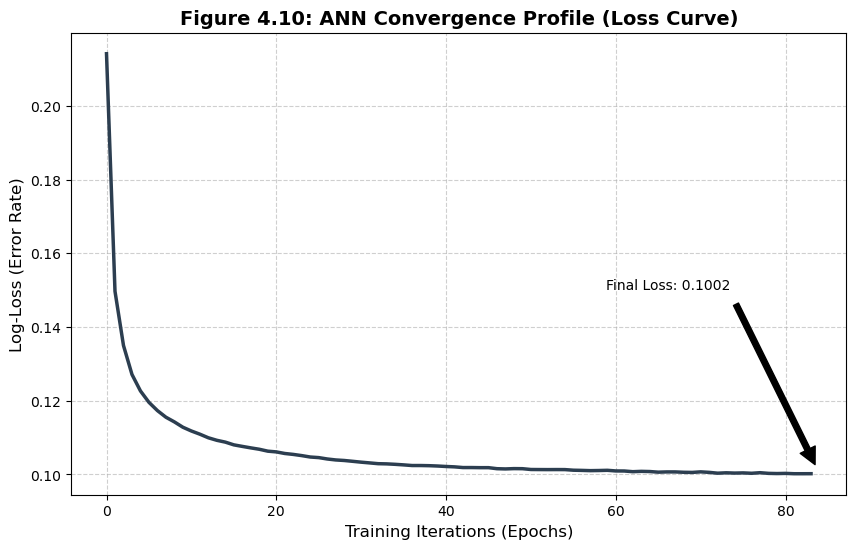

In [125]:
import matplotlib.pyplot as plt

best_mlp = random_search.best_estimator_

plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(best_mlp.loss_curve_, color='#2c3e50', linewidth=2.5)

plt.title('Figure 4.10: ANN Convergence Profile (Loss Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Training Iterations (Epochs)', fontsize=12)
plt.ylabel('Log-Loss (Error Rate)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

final_loss = best_mlp.loss_curve_[-1]
plt.annotate(f'Final Loss: {final_loss:.4f}', 
             xy=(len(best_mlp.loss_curve_), final_loss), 
             xytext=(len(best_mlp.loss_curve_)*0.7, final_loss + 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

In [126]:
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print("Is GPU available?", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
Is GPU available? []


In [127]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

In [128]:
print("Calculating Feature Importance (Permutation Method)...")
# We use a 5,000-row sample for speed while maintaining statistical rigor
# Using the best_estimator_ from successful RandomizedSearch
result = permutation_importance(random_search.best_estimator_, 
                                X_test_knn[:5000], y_test[:5000], 
                                n_repeats=5, random_state=42)


Calculating Feature Importance (Permutation Method)...


In [129]:
# We use X_train.columns because the NumPy array lost its labels
importance_df = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

# Display the top drivers for your Result interpretation
print(importance_df.head(10))

                    Feature  Importance
0      Avg_Spend_Per_Tenure     0.17460
2         Support_Call_Rate     0.16140
3        Payment_Delay_Rate     0.10308
10  Contract Length_Monthly     0.10048
1          Usage_Per_Tenure     0.07048
7               Gender_Male     0.06424
4             Recency_Score     0.06132
15          Age_Group_56-65     0.05948
6                 High_Risk     0.04868
5          Engagement_Score     0.02984


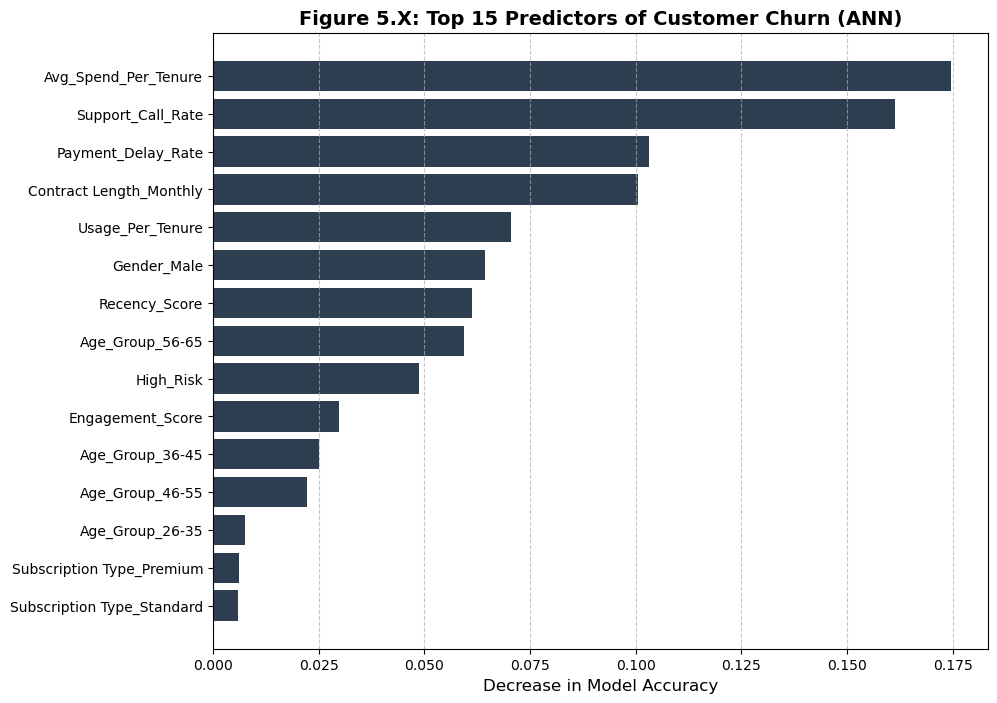


--- Key Research Insights ---
                    Feature  Importance
0      Avg_Spend_Per_Tenure     0.17460
2         Support_Call_Rate     0.16140
3        Payment_Delay_Rate     0.10308
10  Contract Length_Monthly     0.10048
1          Usage_Per_Tenure     0.07048


In [130]:
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].head(15), importance_df['Importance'].head(15), color='#2c3e50')
plt.xlabel('Decrease in Model Accuracy', fontsize=12)
plt.title('Figure 5.X: Top 15 Predictors of Customer Churn (ANN)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Key Research Insights ---")
print(importance_df.head(5))

In [146]:
param_dist = {
    'hidden_layer_sizes': [(100, 50, 25), (100,)],
    'activation': ['relu'],
    'alpha': [0.0001]
}
print("Best parameters selected by RandomizedSearchCV:")
print(random_search.best_params_)
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

Best parameters selected by RandomizedSearchCV:
{'hidden_layer_sizes': (100,), 'alpha': 0.0001, 'activation': 'relu'}
Best cross-validation score: 0.9626


In [131]:
from sklearn.metrics import confusion_matrix

# 1. Get the Confusion Matrix from your ANN
y_pred = random_search.best_estimator_.predict(X_test_knn)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# 2. Business Logic: 
# Saving a churner (TP) saves $100. 
# Marketing to a non-churner (FP) costs $20.
savings = (tp * 100) - (fp * 20)

print(f"--- Strategic Business Impact ---")
print(f"Total Customers correctly identified for retention: {tp}")
print(f"Estimated Annual Savings: ${savings:,}")

--- Strategic Business Impact ---
Total Customers correctly identified for retention: 47449
Estimated Annual Savings: $4,729,680


In [132]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

In [133]:
# Build a refined Deep ANN using the new Input layer standard
model = Sequential([
    Input(shape=(X_train_knn.shape[1],)), # New standard for Keras 3.x
    Dense(128, activation='relu'),
    Dropout(0.2), 
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Training Final Keras Deep ANN (Clean Mode)...
Epoch 1/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8826 - loss: 0.2771 - val_accuracy: 0.9301 - val_loss: 0.1809
Epoch 2/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9287 - loss: 0.1825 - val_accuracy: 0.9440 - val_loss: 0.1504
Epoch 3/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9414 - loss: 0.1550 - val_accuracy: 0.9521 - val_loss: 0.1318
Epoch 4/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9485 - loss: 0.1379 - val_accuracy: 0.9560 - val_loss: 0.1216
Epoch 5/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9525 - loss: 0.1288 - val_accuracy: 0.9576 - val_loss: 0.1169
Epoch 6/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9545 - loss: 0.1235 - val_accuracy: 0.9587 - val_loss: 0.1136
Epoch 7/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9563 - loss: 0.1199 - val_accuracy: 0.9601 - val_loss: 0.1100
Epoch 8/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accu

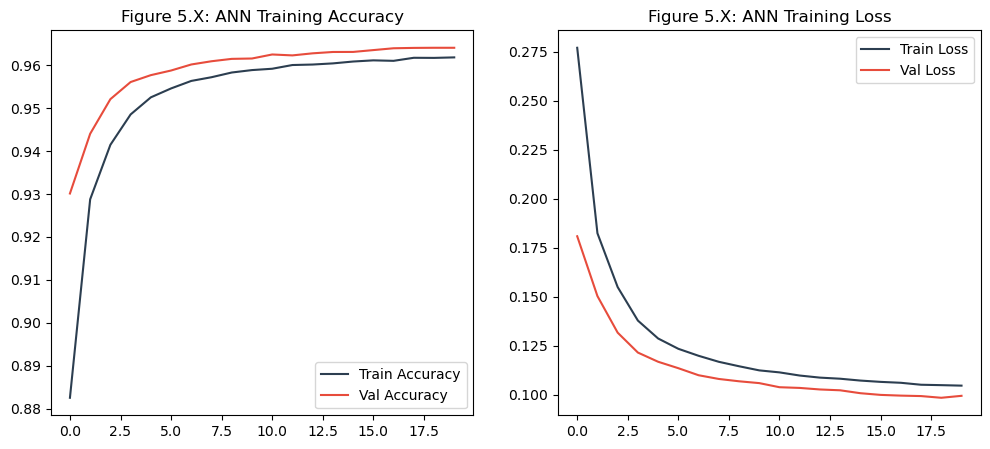

In [134]:
print("Training Final Keras Deep ANN (Clean Mode)...")
history = model.fit(X_train_knn, y_train, 
                    epochs=20, 
                    batch_size=1024, 
                    validation_split=0.2, 
                    verbose=1)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#2c3e50')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#e74c3c')
plt.title('Figure 5.X: ANN Training Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#2c3e50')
plt.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
plt.title('Figure 5.X: ANN Training Loss')
plt.legend()
plt.show()

In [136]:
# Test-set evaluation of the Keras Sequential ANN
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

# Generate predictions on the held-out test set
y_prob_keras = model.predict(X_test_knn).flatten()
y_pred_keras = (y_prob_keras >= 0.5).astype(int)



2756/2756 ━━━━━━━━━━━━━━━━━━━━ 2s 759us/step


In [137]:
# Compute the five evaluation metrics
acc_keras  = accuracy_score(y_test, y_pred_keras)
prec_keras = precision_score(y_test, y_pred_keras)
rec_keras  = recall_score(y_test, y_pred_keras)
f1_keras   = f1_score(y_test, y_pred_keras)
roc_keras  = roc_auc_score(y_test, y_prob_keras)

print("Keras Sequential ANN — Test Set Performance")
print(f"Accuracy : {acc_keras:.4f}")
print(f"Precision: {prec_keras:.4f}")
print(f"Recall   : {rec_keras:.4f}")
print(f"F1-Score : {f1_keras:.4f}")
print(f"ROC-AUC  : {roc_keras:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_keras))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_keras))

Keras Sequential ANN — Test Set Performance
Accuracy : 0.9622
Precision: 0.9894
Recall   : 0.9435
F1-Score : 0.9659
ROC-AUC  : 0.9908

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96     38167
         1.0       0.99      0.94      0.97     50000

    accuracy                           0.96     88167
   macro avg       0.96      0.97      0.96     88167
weighted avg       0.96      0.96      0.96     88167


Confusion Matrix:
[[37662   505]
 [ 2824 47176]]


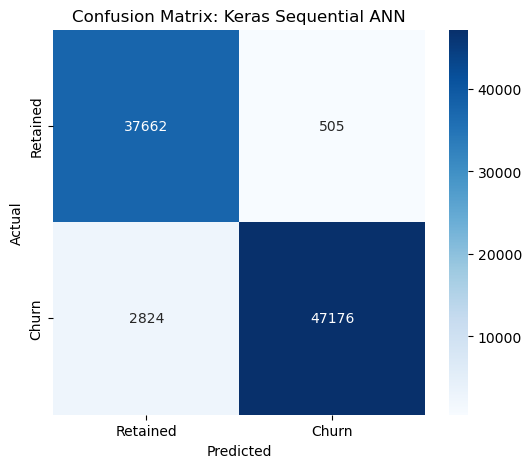

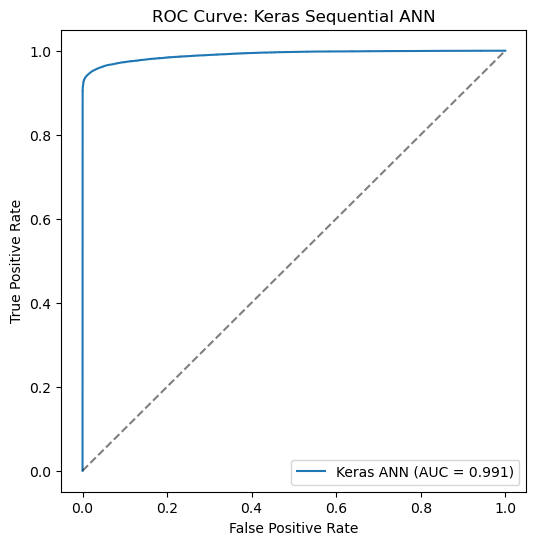

In [138]:
# Confusion matrix figure
import seaborn as sns
import matplotlib.pyplot as plt

cm_keras = confusion_matrix(y_test, y_pred_keras)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_keras, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churn'],
            yticklabels=['Retained', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Keras Sequential ANN')
plt.savefig('confusion_matrix_keras.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC curve figure
from sklearn.metrics import roc_curve
fpr_k, tpr_k, _ = roc_curve(y_test, y_prob_keras)
plt.figure(figsize=(6, 6))
plt.plot(fpr_k, tpr_k, label=f'Keras ANN (AUC = {roc_keras:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Keras Sequential ANN')
plt.legend(loc='lower right')
plt.savefig('roc_curve_keras.png', dpi=300, bbox_inches='tight')
plt.show()

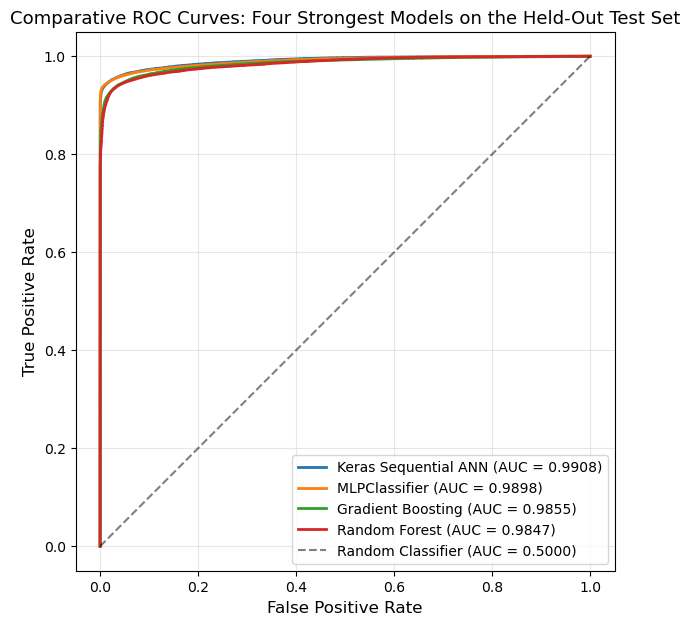

In [141]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute FPR and TPR for each of the four strongest models
fpr_mlp,    tpr_mlp,    _ = roc_curve(y_test, y_prob_mlp)
fpr_gb,     tpr_gb,     _ = roc_curve(y_test, y_prob_gb)
fpr_rf,     tpr_rf,     _ = roc_curve(y_test, y_pred_prob_rf)
fpr_keras,  tpr_keras,  _ = roc_curve(y_test, y_prob_keras)

# Set up the figure
plt.figure(figsize=(8, 7))

# Plot each ROC curve with the AUC value in the legend
plt.plot(fpr_keras, tpr_keras,
         label=f'Keras Sequential ANN (AUC = {roc_auc_score(y_test, y_prob_keras):.4f})',
         linewidth=2)

plt.plot(fpr_mlp, tpr_mlp,
         label=f'MLPClassifier (AUC = {roc_auc_score(y_test, y_prob_mlp):.4f})',
         linewidth=2)

plt.plot(fpr_gb, tpr_gb,
         label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_gb):.4f})',
         linewidth=2)

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_prob_rf):.4f})',
         linewidth=2)

# Add the diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier (AUC = 0.5000)')

# Axes labels and title
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Comparative ROC Curves: Four Strongest Models on the Held-Out Test Set',
          fontsize=13)

# Legend in the lower right
plt.legend(loc='lower right', fontsize=10)

# Grid for readability
plt.grid(True, alpha=0.3)

# Equal aspect ratio so the diagonal looks at 45 degrees
plt.gca().set_aspect('equal', adjustable='box')

# Save to disk at 300 dpi for thesis quality
plt.savefig('roc_curves_top_four_models.png', dpi=300, bbox_inches='tight')

plt.show()

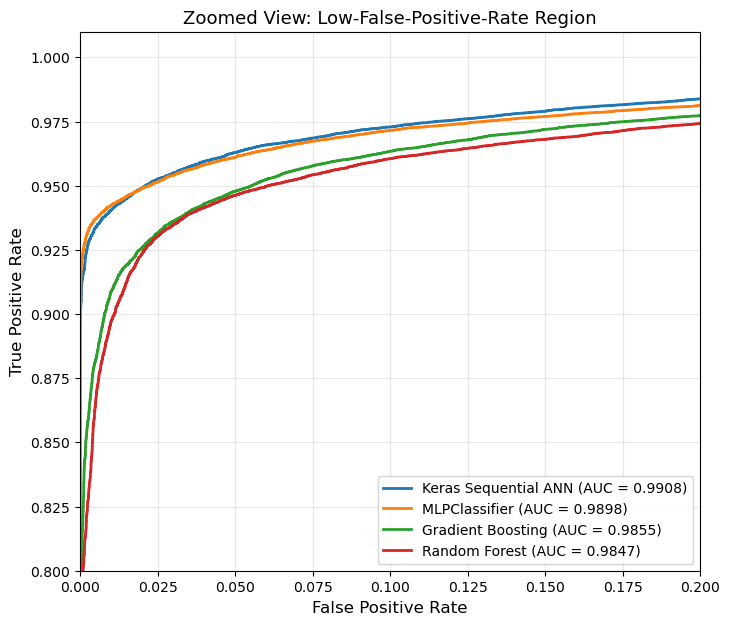

In [143]:
# Zoomed-in view to show the difference in the low-FPR region
plt.figure(figsize=(8, 7))

plt.plot(fpr_keras, tpr_keras,
         label=f'Keras Sequential ANN (AUC = {roc_auc_score(y_test, y_prob_keras):.4f})',
         linewidth=2)
plt.plot(fpr_mlp, tpr_mlp,
         label=f'MLPClassifier (AUC = {roc_auc_score(y_test, y_prob_mlp):.4f})',
         linewidth=2)
plt.plot(fpr_gb, tpr_gb,
         label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_gb):.4f})',
         linewidth=2)
plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_prob_rf):.4f})',
         linewidth=2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Zoomed View: Low-False-Positive-Rate Region', fontsize=13)
plt.xlim(0, 0.2)
plt.ylim(0.8, 1.01)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig('roc_curves_zoomed.png', dpi=300, bbox_inches='tight')
plt.show()

In [154]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []

for t in thresholds:
    y_pred_t = (y_prob_shallow >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    rows.append({
        'Threshold': t,
        'Precision (Churn)': round(precision_score(y_test, y_pred_t), 4),
        'Recall (Churn)':    round(recall_score(y_test, y_pred_t), 4),
        'F1 (Churn)':        round(f1_score(y_test, y_pred_t), 4),
        'False Positives':   int(fp),
        'False Negatives':   int(fn),
    })

threshold_table = pd.DataFrame(rows)
print(threshold_table.to_string(index=False))

 Threshold  Precision (Churn)  Recall (Churn)  F1 (Churn)  False Positives  False Negatives
       0.3             0.9615          0.9618      0.9616             1926             1911
       0.4             0.9754          0.9550      0.9651             1205             2249
       0.5             0.9842          0.9490      0.9663              761             2551
       0.6             0.9896          0.9434      0.9660              494             2831
       0.7             0.9936          0.9373      0.9646              300             3136


In [156]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    random_search.best_estimator_,   # the single-layer MLP
    X_test_knn, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': X_test.columns,                  # <-- use X_test (DataFrame), not X_test_knn (array)
    'Importance': result.importances_mean,
    'Std': result.importances_std
}).sort_values('Importance', ascending=False)

print(importance_df.head(15).to_string(index=False))

                   Feature  Importance      Std
      Avg_Spend_Per_Tenure    0.172033 0.000990
         Support_Call_Rate    0.165062 0.001319
        Payment_Delay_Rate    0.104153 0.000631
   Contract Length_Monthly    0.098724 0.000511
          Usage_Per_Tenure    0.074547 0.000493
               Gender_Male    0.067436 0.000608
             Recency_Score    0.067287 0.000552
           Age_Group_56-65    0.057544 0.000437
                 High_Risk    0.044960 0.000769
          Engagement_Score    0.030523 0.000546
           Age_Group_36-45    0.026770 0.000524
           Age_Group_46-55    0.021139 0.000325
           Age_Group_26-35    0.008280 0.000261
Subscription Type_Standard    0.006581 0.000277
 Subscription Type_Premium    0.006470 0.000268


In [159]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []

for t in thresholds:
    y_pred_t = (y_prob_shallow >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    rows.append({
        'Threshold': t,
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp),
        'Precision (Churn)': round(precision_score( y_test, y_pred_t), 4),
        'Recall (Churn)':    round(recall_score(y_test, y_pred_t), 4),
        'F1 (Churn)':        round(f1_score(y_test, y_pred_t), 4),
    })

threshold_table = pd.DataFrame(rows)
print(threshold_table.to_string(index=False))

 Threshold    TN   FP   FN    TP  Precision (Churn)  Recall (Churn)  F1 (Churn)
       0.3 36241 1926 1911 48089             0.9615          0.9618      0.9616
       0.4 36962 1205 2249 47751             0.9754          0.9550      0.9651
       0.5 37406  761 2551 47449             0.9842          0.9490      0.9663
       0.6 37673  494 2831 47169             0.9896          0.9434      0.9660
       0.7 37867  300 3136 46864             0.9936          0.9373      0.9646
